# Visualization

> Complete visualization workflow: sidecar creation, aggregation, and map display

## Setup

Import the healpyxel package and core utilities:

In [1]:
import healpyxel
from healpyxel import core
import pandas as pd
import numpy as np

print(f"healpyxel version: {healpyxel.__version__}")

healpyxel version: 0.1.0


## Test Data

Check available test data in the package:

In [2]:
from pathlib import Path

# Look for test data
test_data_dir = Path('../test_data')
if test_data_dir.exists():
    print("Test data directory found!")
    print(f"\nContents:")
    for item in sorted(test_data_dir.iterdir()):
        if item.is_file():
            size_mb = item.stat().st_size / 1024 / 1024
            print(f"  {item.name}: {size_mb:.2f} MB")
        elif item.is_dir():
            n_files = len(list(item.glob('*')))
            print(f"  {item.name}/: {n_files} files")
else:
    print("Test data directory not found. Run create_test_data.sh to generate test data.")

Test data directory found!

Contents:
  README.md: 0.00 MB
  batches/: 11 files
  regions/: 0 files
  samples/: 4 files
  validation/: 2 files


## Quick Test with Sample Data

If test data is available, let's try a quick aggregation:

In [5]:
# Check for sample data
sample_file = test_data_dir / 'samples/sample_50k.parquet'

if sample_file.exists():
    print(f"Loading sample: {sample_file.name}")
    df = pd.read_parquet(sample_file)
    
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nFirst few rows:")
    display(df.head())
    
    # Check for lat/lon columns
    if 'latitude' in df.columns and 'longitude' in df.columns:
        print(f"\n✓ Found latitude/longitude columns for HEALPix conversion")
        print(f"  Lat range: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
        print(f"  Lon range: [{df['longitude'].min():.2f}, {df['longitude'].max():.2f}]")
else:
    print("Sample data not found. Generate test data first:")
    print("  cd .. && bash create_test_data.sh")

Loading sample: sample_50k.parquet

Shape: (50000, 61)

Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'geometry']

First few rows:


,ref_id,a,b,c,d,e,f,g,h,i,...,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,1221107223201068,0,1,1,2,9,1,1,0,0,...,5.927996,59.658302,1901453.4,884.02386,2738.6200,25.221247,52.641087,77.85977,129.176030,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
1,1124821221900340,0,1,1,2,9,1,1,0,0,...,0.317725,303.638760,1062135.2,599.24713,2256.7527,56.044827,21.791897,77.82958,97.918365,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00..."
2,1221902412000176,0,2,2,2,9,1,1,0,0,...,-68.457260,23.021687,22254792.0,4192.15530,6759.2153,68.652030,33.230824,101.83984,107.450775,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
3,1308423281701252,0,0,0,0,9,1,1,0,0,...,6.530286,240.178450,1333903.5,859.48000,1976.0538,53.991188,23.853260,77.83787,99.408930,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...
4,1334901094500334,0,0,0,0,9,1,1,0,0,...,3.555044,51.978970,1012146.3,604.04944,2133.4424,61.469143,16.375393,77.83818,94.556915,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00...


In [ ]:
import duckdb
from math import isnan
import pathlib
stats = []
# reuse/clear existing stats list
stats.clear()

# print("\nInspecting all parquet files in test data directory and collecting lat/lon stats:")
for parquet_file in test_data_dir.rglob('*.parquet'):
    size_mb = parquet_file.stat().st_size / 1024 / 1024
    rel = parquet_file.relative_to(test_data_dir)
    try:
        q = (
            f"SELECT COUNT(*) AS n_rows, "
            f"MIN(lat_center) AS lat_min, MAX(lat_center) AS lat_max, "
            f"MIN(lon_center) AS lon_min, MAX(lon_center) AS lon_max "
            f"FROM read_parquet('{parquet_file.as_posix()}')"
        )
        n_rows, lat_min, lat_max, lon_min, lon_max = duckdb.query(q).fetchone()
    except Exception:
        # If lat_center/lon_center missing or another error, still try to get row count
        try:
            n_rows = duckdb.query(f"SELECT COUNT(*) FROM read_parquet('{parquet_file.as_posix()}')").fetchone()[0]
        except Exception:
            n_rows = None
        lat_min = lat_max = lon_min = lon_max = None

    stats.append({
        "file": str(rel),
        "size_mb": size_mb,
        "n_rows": n_rows,
        "lat_min": lat_min,
        "lat_max": lat_max,
        "lon_min": lon_min,
        "lon_max": lon_max,
    })
    # print(f"  {rel}: {size_mb:.2f} MB, {n_rows} rows")

# Aggregate into a dataframe and display
df_stats = pd.DataFrame(stats)
df_stats['filename'] = df_stats['file'].apply(lambda x: pathlib.Path(x).stem)
display(df_stats)

,file,size_mb,n_rows,lat_min,lat_max,lon_min,lon_max,filename
0,samples/sample_50k.parquet,18.907251,50000,-75.011170,74.860380,0.023469,359.96622,sample_50k
1,samples/sample_5k.parquet,1.938233,5000,-74.987915,74.925750,0.068102,359.82980,sample_5k
2,samples/sample_25k.parquet,9.599403,25000,-74.999180,74.782600,0.044146,359.95227,sample_25k
3,validation/high_quality_subset.parquet,9.039520,25121,-74.992330,74.683150,175.000180,184.99979,high_quality_subset
4,validation/combined_batch_001_003.parquet,3.963549,10890,-74.627014,74.447170,175.000180,177.99991,combined_batch_001_003
5,batches/batch_009.parquet,1.613872,4417,-74.822310,74.647300,183.000080,183.99973,batch_009
6,batches/batch_003.parquet,1.373711,3734,-73.450960,74.447170,177.000500,177.99991,batch_003
7,batches/batch_007.parquet,1.530560,4174,-73.332790,74.656006,181.000610,181.99995,batch_007
8,batches/batch_010.parquet,1.800152,4931,-74.797844,74.683150,184.000270,184.99979,batch_010
9,batches/batch_004.parquet,1.463713,3990,-74.927130,74.425640,178.000030,178.99997,batch_004


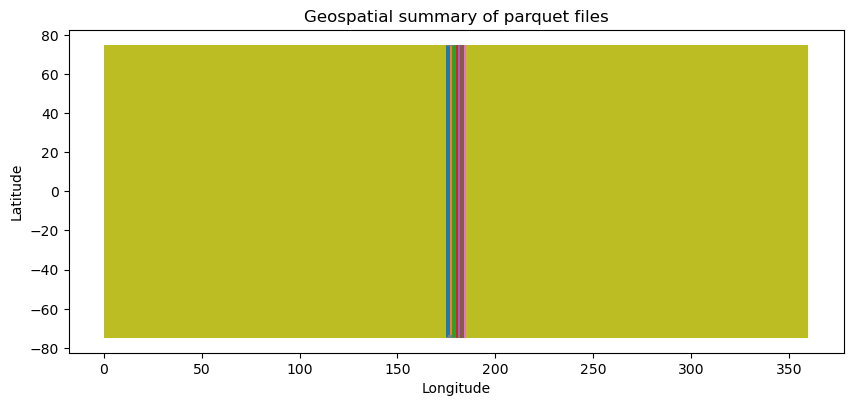

In [ ]:
# convert to geopandas creating a polygon box with lat_min	lat_max	lon_min	lon_max per file
import geopandas as gpd
from shapely.geometry import box
df_stats['geometry'] = df_stats.apply(
    lambda row: box(row['lon_min'], row['lat_min'], row['lon_max'], row['lat_max'])
    if not (isnan(row['lat_min']) or isnan(row['lat_max']) or isnan(row['lon_min']) or isnan(row['lon_max']))
    else None,
    axis=1
)
gdf_stats = gpd.GeoDataFrame(df_stats, geometry='geometry', crs='EPSG:4326')
ax = gdf_stats.plot(column='filename', legend=False, figsize=(10, 6))
ax.set_title("Geospatial summary of parquet files")
ax.set_xlabel("Longitude");
ax.set_ylabel("Latitude");

Text(0.5, 1.0, 'Geospatial coverage of parquet files (excluding sample files)')

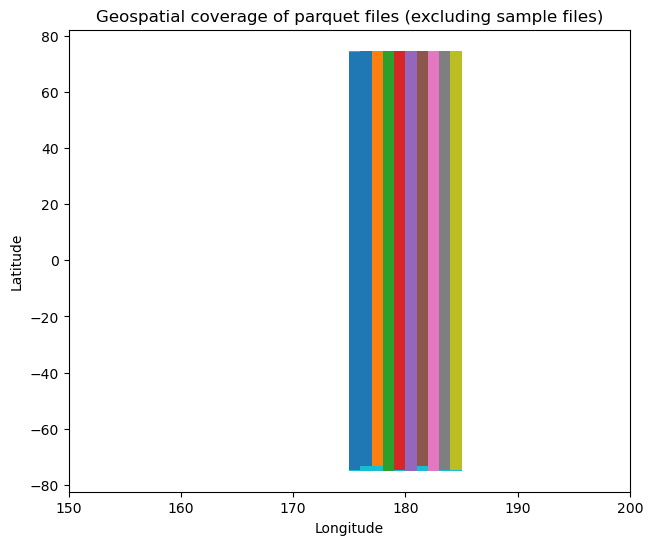

In [ ]:
# convert to geopandas creating a polygon box with lat_min	lat_max	lon_min	lon_max per file
ax = gdf_stats[~gdf_stats.filename.str.contains('sample')].plot(column='filename', legend=False, figsize=(20, 6), aspect=0.25)
ax.set_xlim([150, 200])
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geospatial coverage of parquet files (excluding sample files)')


## Create Sidecar for Sample Data

Now let's create a HEALPix sidecar for the sample data. We can do this in memory without writing to a file.

In [ ]:
# Load the 50k sample
import geopandas as gpd
from shapely import wkb

sample_file = test_data_dir / 'samples' / 'sample_50k.parquet'
print(f"Loading: {sample_file}")

# Read as regular pandas DataFrame first (geometry is stored as WKB binary)
df = pd.read_parquet(sample_file)
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

# Convert WKB geometry column to shapely geometries
if 'geometry' in df.columns:
    print("\nConverting WKB geometry to GeoDataFrame...")
    df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)) if x is not None else None)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    print(f"CRS: {gdf.crs}")
else:
    print("\nNo geometry column found!")
    gdf = df

# Show first few rows
gdf.head(3)

Loading: ../test_data/samples/sample_50k.parquet
Loaded 50000 rows
Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'geometry']

Converting WKB geometry to GeoDataFrame...
CRS: EPSG:4326
CRS: EPSG:4326


,ref_id,a,b,c,d,e,f,g,h,i,...,lat_center,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,geometry
0,1221107223201068,0,1,1,2,9,1,1,0,0,...,5.927996,59.658302,1901453.4,884.02386,2738.6200,25.221247,52.641087,77.85977,129.176030,"POLYGON ((59.63697 5.9037, 59.66616 5.92117, 5..."
1,1124821221900340,0,1,1,2,9,1,1,0,0,...,0.317725,303.638760,1062135.2,599.24713,2256.7527,56.044827,21.791897,77.82958,97.918365,"POLYGON ((303.6493 0.29339, 303.64523 0.32052,..."
2,1221902412000176,0,2,2,2,9,1,1,0,0,...,-68.457260,23.021687,22254792.0,4192.15530,6759.2153,68.652030,33.230824,101.83984,107.450775,"POLYGON ((23.04131 -68.53648, 23.15511 -68.452..."


In [ ]:
# Create sidecar in memory using the process_partition function
from healpyxel.sidecar import process_partition

# Parameters
nside = 32  # HEALPix resolution
mode = 'fuzzy'  # 'fuzzy' allows multiple cells per geometry, 'strict' only single-cell geometries

# Process the GeoDataFrame
sidecar_df = process_partition(
    gdf=gdf,
    nside=nside,
    mode=mode,
    base_index=0,  # Start source_id from 0
    lon_convention='0_360',  # Use '0_360' or '-180_180' (underscores, not hyphens!)
)

print(f"Created sidecar with {len(sidecar_df)} assignments")
print(f"Unique geometries: {sidecar_df['source_id'].nunique()}")
print(f"Unique HEALPix cells: {sidecar_df['healpix_id'].nunique()}")
print(f"\nSidecar columns: {list(sidecar_df.columns)}")
print(f"Sidecar dtypes:\n{sidecar_df.dtypes}")

# Show first few assignments
sidecar_df.head(10)

2025-12-12 13:02:29,798 INFO Partition (lon_convention=0_360): processed 50000 geometries, dropped 17 (0.0%) total [pre-filter: 17, post-processing: 0]


Created sidecar with 54888 assignments
Unique geometries: 49983
Unique HEALPix cells: 10825

Sidecar columns: ['source_id', 'healpix_id']
Sidecar dtypes:
source_id      int64
healpix_id    UInt64
dtype: object


,source_id,healpix_id
0,0,5815
1,1,7536
2,2,8333
3,3,7906
4,4,5805
5,4,5807
6,5,9771
7,5,9857
8,6,7355
9,7,12212


In [ ]:
# Check how many cells each geometry touches (for fuzzy mode)
assignments_per_geom = sidecar_df.groupby('source_id').size()

print(f"Assignment statistics:")
print(f"  Min cells per geometry: {assignments_per_geom.min()}")
print(f"  Max cells per geometry: {assignments_per_geom.max()}")
print(f"  Mean cells per geometry: {assignments_per_geom.mean():.2f}")
print(f"  Median cells per geometry: {assignments_per_geom.median():.0f}")

# Show distribution
print(f"\nDistribution of assignments per geometry:")
print(assignments_per_geom.value_counts().sort_index().head(10))

Assignment statistics:
  Min cells per geometry: 1
  Max cells per geometry: 4
  Mean cells per geometry: 1.10
  Median cells per geometry: 1

Distribution of assignments per geometry:
1    45380
2     4327
3      250
4       26
Name: count, dtype: int64


In [ ]:
# Optional: Save sidecar to file for later use
sidecar_output = pathlib.Path(f'/tmp/sample_50k_sidecar_nside{nside}_{mode}.parquet')
sidecar_df.to_parquet(sidecar_output, index=False)
print(f"Saved sidecar to: {sidecar_output}")
print(f"File size: {sidecar_output.stat().st_size / 1024:.2f} KB")

Saved sidecar to: /tmp/sample_50k_sidecar_nside32_fuzzy.parquet
File size: 440.74 KB


## Aggregate Data by HEALPix Cells

Now let's use the sidecar to aggregate the `r1050` column from the original data by HEALPix cells.

In [ ]:
# Import the aggregate module
from healpyxel.aggregate import aggregate_by_sidecar

# Check if r1050 column exists
if 'r1050' in gdf.columns:
    print("✓ Column 'r1050' found in the data")
    print(f"  Range: [{gdf['r1050'].min():.3f}, {gdf['r1050'].max():.3f}]")
    print(f"  Missing values: {gdf['r1050'].isna().sum()} / {len(gdf)}")
else:
    print("❌ Column 'r1050' not found!")
    print(f"Available columns: {list(gdf.columns)}")

✓ Column 'r1050' found in the data
  Range: [-0.003, 0.174]
  Missing values: 0 / 50000


In [ ]:
# Aggregate r1050 by HEALPix cells with explicit aggregation functions
# Convert GeoDataFrame to regular DataFrame for aggregation (geometry not needed)
df_for_agg = pd.DataFrame(gdf.drop(columns='geometry'))

# Perform aggregation with all available functions explicitly
aggregated = aggregate_by_sidecar(
    original=df_for_agg,
    sidecar=sidecar_df,
    value_columns=['r1050'],
    aggs=['mean', 'median', 'std', 'mad', 'robust_std'],  # Explicit list of aggregations
    source_id_col='source_id',
    healpix_col='healpix_id',
    min_count=1,  # Minimum number of sources per cell
    include_counts=True,  # Include count columns
    sentinel_threshold=1e30  # Mask extreme values
)

print(f"Aggregated data shape: {aggregated.shape}")
print(f"Number of HEALPix cells with data: {len(aggregated)}")
print(f"\nAggregated columns: {list(aggregated.columns)}")

# Show first few rows
aggregated.head(10)

2025-12-12 13:02:30,012 INFO Starting aggregation for 1 column(s): ['r1050']
2025-12-12 13:02:30,012 INFO Aggregation functions: ['mean', 'median', 'std', 'mad', 'robust_std']
2025-12-12 13:02:30,021 INFO Creating source_id column from DataFrame index
2025-12-12 13:02:30,012 INFO Aggregation functions: ['mean', 'median', 'std', 'mad', 'robust_std']
2025-12-12 13:02:30,021 INFO Creating source_id column from DataFrame index
2025-12-12 13:02:30,055 INFO Sidecar source_id overlap: 49983/49983 (100.0%)
2025-12-12 13:02:30,055 INFO Merging sidecar with original data
2025-12-12 13:02:30,060 INFO Grouping by healpix_id and computing aggregations
2025-12-12 13:02:30,055 INFO Sidecar source_id overlap: 49983/49983 (100.0%)
2025-12-12 13:02:30,055 INFO Merging sidecar with original data
2025-12-12 13:02:30,060 INFO Grouping by healpix_id and computing aggregations
2025-12-12 13:02:30,127 INFO Processing 10825 HEALPix cells
2025-12-12 13:02:30,127 INFO Processing 10825 HEALPix cells


Aggregating HEALPix cells:   0%|          | 0/10825 [00:00<?, ?cell/s]

2025-12-12 13:02:33,399 INFO Creating output DataFrame with 10825 cells
2025-12-12 13:02:33,423 INFO Aggregation complete. Output shape: (10825, 6)
2025-12-12 13:02:33,423 INFO Aggregation complete. Output shape: (10825, 6)


Aggregated data shape: (10825, 6)
Number of HEALPix cells with data: 10825

Aggregated columns: ['r1050_mean', 'r1050_median', 'r1050_std', 'r1050_mad', 'r1050_robust_std', 'n_sources']


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,0.047764,0.047652,0.001116,0.000877,0.001300,4
1,0.055255,0.055561,0.009401,0.001885,0.002795,5
2,0.050887,0.051560,0.003475,0.002050,0.003039,5
3,0.052687,0.053003,0.001374,0.001186,0.001759,3
4,0.048042,0.048304,0.003802,0.003442,0.005103,4
5,0.052645,0.052189,0.004026,0.003416,0.005065,4
6,0.058018,0.056681,0.003631,0.000435,0.000645,5
7,0.048398,0.048118,0.002235,0.001603,0.002377,4
8,0.048196,0.049001,0.001647,0.001294,0.001918,5


### Interpret the Results

Each row represents one HEALPix cell with:
- `healpix_id`: The HEALPix cell identifier
- `r1050_mean`: Mean of r1050 values in this cell
- `r1050_median`: Median value (less affected by outliers)
- `r1050_std`: Standard deviation (spread of values)
- `r1050_mad`: Median Absolute Deviation (robust measure of spread)
- `r1050_robust_std`: MAD * 1.4826 (approximates standard deviation for normal distributions)
- `n_sources`: Number of source measurements in this cell, for all columns

Let's examine the statistics of the aggregated data:

In [ ]:
# Display summary statistics of the aggregated results
print("Summary statistics for aggregated HEALPix cells:\n")
print(aggregated.describe())

# Check distribution of source counts per cell
print("\n\nDistribution of source counts per HEALPix cell:")
print(aggregated['n_sources'].describe())
print(f"\nCells with only 1 source: {(aggregated['n_sources'] == 1).sum()}")
print(f"Cells with 2-5 sources: {((aggregated['n_sources'] >= 2) & (aggregated['n_sources'] <= 5)).sum()}")
print(f"Cells with 5+ sources: {(aggregated['n_sources'] > 5).sum()}")

Summary statistics for aggregated HEALPix cells:

         r1050_mean  r1050_median     r1050_std     r1050_mad  \
count  10825.000000  10825.000000  10825.000000  10825.000000   
mean       0.054775      0.054660      0.004834      0.003116   
std        0.008045      0.008020      0.004080      0.003007   
min        0.019774      0.019774      0.000000      0.000000   
25%        0.049531      0.049424      0.001914      0.000998   
50%        0.053805      0.053680      0.004271      0.002541   
75%        0.059047      0.058956      0.006892      0.004357   
max        0.129722      0.129722      0.050240      0.050240   

       r1050_robust_std     n_sources  
count      10825.000000  10825.000000  
mean           0.004620      5.070485  
std            0.004458      4.811633  
min            0.000000      1.000000  
25%            0.001479      2.000000  
50%            0.003767      4.000000  
75%            0.006459      6.000000  
max            0.074486     85.000000  


Di

### HEALPix Metadata

The aggregation results don't automatically include HEALPix metadata. You need to track this separately or read it from a saved sidecar file. For in-memory workflows, store metadata explicitly:

In [ ]:
# Store HEALPix metadata with aggregated results
metadata = {
    'healpix_nside': nside,
    'healpix_order': 'nested',  # HEALPix default in healpyxel
    'healpix_mode': mode,
}

# Access metadata like in your older scripts
nside_value = int(metadata['healpix_nside'])
order = metadata['healpix_order']
nest_flag = (order == 'nested')

print(f"HEALPix Configuration:")
print(f"  nside: {nside_value}")
print(f"  order: {order}")
print(f"  nested: {nest_flag}")
print(f"  mode: {metadata['healpix_mode']}")

HEALPix Configuration:
  nside: 32
  order: nested
  nested: True
  mode: fuzzy


**Reading metadata from saved sidecar files:**

If you save the sidecar to a parquet file (like we did earlier), the metadata is embedded in the parquet schema and can be read back:

In [ ]:
# Read metadata from saved sidecar file
import pyarrow.parquet as pq

sidecar_file = pathlib.Path(f'/tmp/sample_50k_sidecar_nside{nside}_{mode}.parquet')
if sidecar_file.exists():
    # Read parquet metadata
    parquet_file = pq.ParquetFile(sidecar_file)
    schema_metadata = parquet_file.schema_arrow.metadata
    
    # Decode metadata (stored as bytes)
    file_metadata = {k.decode(): v.decode() for k, v in schema_metadata.items()} if schema_metadata else {}
    
    print("Metadata from saved sidecar file:")
    print(f"  nside: {file_metadata.get('nside', 'N/A')}")
    print(f"  mode: {file_metadata.get('mode', 'N/A')}")
    print(f"  order: {file_metadata.get('order', 'N/A')}")
    
    # Use it like your older scripts
    if 'nside' in file_metadata:
        nside_from_file = int(file_metadata['nside'])
        order_from_file = file_metadata['order']
        nest_flag_from_file = (order_from_file == 'nested')
        print(f"\n  → nest_flag: {nest_flag_from_file}")
else:
    print(f"Sidecar file not found: {sidecar_file}")

Metadata from saved sidecar file:
  nside: N/A
  mode: N/A
  order: N/A


## Visualize HEALPix Map

Before visualizing, we need to densify the sparse aggregated data to include all HEALPix cells (including empty ones).

We'll use the visualization utilities from `healpyxel.visualization` module.

In [ ]:
# Densify the aggregated data to include all HEALPix cells
from healpyxel.aggregate import densify_healpix_aggregates

# The aggregated DataFrame only contains cells with data (sparse)
# Densify to create a full HEALPix grid with all npix = 12 * nside^2 cells
aggregated_dense = densify_healpix_aggregates(
    agg_sparse_df=aggregated,
    nside=nside,
    index_name='healpix_id'
)

print(f"Sparse aggregated cells: {len(aggregated)}")
print(f"Dense HEALPix grid cells: {len(aggregated_dense)} (expected: {12 * nside**2})")
print(f"\nEmpty cells (no data): {aggregated_dense['r1050_median'].isna().sum()}")
print(f"Cells with data: {aggregated_dense['r1050_median'].notna().sum()}")

# Show first few rows including empty cells
aggregated_dense.head(10)

2025-12-12 13:02:33,586 INFO Densified to 12288 cells (added 1463 empty cells)


Sparse aggregated cells: 10825
Dense HEALPix grid cells: 12288 (expected: 12288)

Empty cells (no data): 1463
Cells with data: 10825


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,0.047764,0.047652,0.001116,0.000877,0.001300,4
1,0.055255,0.055561,0.009401,0.001885,0.002795,5
2,0.050887,0.051560,0.003475,0.002050,0.003039,5
3,0.052687,0.053003,0.001374,0.001186,0.001759,3
4,0.048042,0.048304,0.003802,0.003442,0.005103,4
5,0.052645,0.052189,0.004026,0.003416,0.005065,4
6,0.058018,0.056681,0.003631,0.000435,0.000645,5
7,0.048398,0.048118,0.002235,0.001603,0.002377,4
8,0.048196,0.049001,0.001647,0.001294,0.001918,5


In [ ]:
# Import visualization utilities from healpyxel
from healpyxel.visualization import prepare_healpix_map
import numpy as np

# Prepare the HEALPix map for visualization
output_column = 'r1050_median'

healpix_map, valid_pixels, invalid_pixels, mappable = prepare_healpix_map(
    aggregated_dense,
    output_column=output_column,
    equalize=True,  # Apply histogram equalization for better contrast
    percentile_cutoff=None,  # Optional: clip outliers, e.g., 5 for [5%, 95%]
    cmap='Spectral_r'
)

print(f"HEALPix map prepared:")
print(f"  Total pixels: {len(healpix_map)}")
print(f"  Valid pixels: {valid_pixels.sum()}")
print(f"  Invalid pixels: {invalid_pixels.sum()}")


HEALPix map prepared:
  Total pixels: 12288
  Valid pixels: 10825
  Invalid pixels: 1463


2025-12-12 13:02:34,529 INFO 0.0 180.0 -180.0 180.0
2025-12-12 13:02:34,529 INFO The interval between parallels is 30 deg -0.00'.
2025-12-12 13:02:34,529 INFO The interval between meridians is 30 deg -0.00'.
2025-12-12 13:02:34,529 INFO The interval between parallels is 30 deg -0.00'.
2025-12-12 13:02:34,529 INFO The interval between meridians is 30 deg -0.00'.


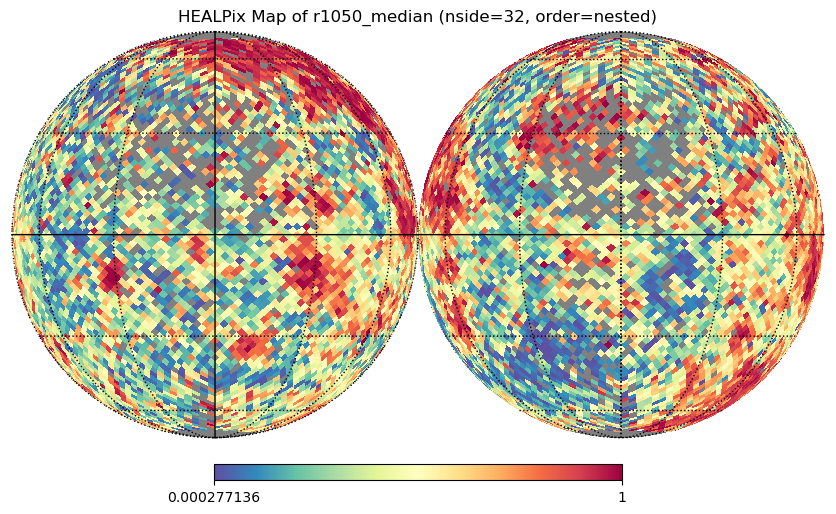

In [ ]:
#| eval: false
import healpy

ax = healpy.visufunc.orthview(healpix_map, nest=nest_flag,
                         title=f'HEALPix Map of {output_column} (nside={nside}, order={order})',
                         cmap='Spectral_r',flip='geo', norm='None', xsize=2500)
healpy.visufunc.graticule()


In [ ]:
import skyproj
from matplotlib import pyplot as plt

In [ ]:
#| eval: false
healpix_map[invalid_pixels] = healpy.UNSEEN
# healpix_map_masked = np.ma.masked_where(invalid_pixels, healpix_map)

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Top row: full-width Mollweide projection
ax_top = fig.add_subplot(gs[0, :])
sp_moll = skyproj.MollweideSkyproj(ax=ax_top, lon_0=-180, longitude_ticks='symmetric')
_ = sp_moll.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=True,
)
fig.colorbar(mappable, ax=sp_moll.ax, orientation='vertical', label=output_column)
sp_moll.ax.set_title(f'Mollweide — global view (nside={nside})')

# Bottom-left: LAEA centered on South pole
ax_bl = fig.add_subplot(gs[1, 0])
sp_south = skyproj.LaeaSkyproj(ax=ax_bl, lat_0=-90.0)
_ = sp_south.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=False,
)
fig.colorbar(mappable, ax=sp_south.ax, orientation='vertical', label=output_column)
sp_south.ax.set_title('LAEA — South pole (lat_0=-90)')

# Bottom-right: LAEA centered on North pole
ax_br = fig.add_subplot(gs[1, 1])
sp_north = skyproj.LaeaSkyproj(ax=ax_br, lat_0=90.0)
_ = sp_north.draw_hpxmap(
    healpix_map,
    nest=nest_flag,
    cmap='Spectral_r',
    zoom=False,
)
fig.colorbar(mappable, ax=sp_north.ax, orientation='vertical', label=output_column)
sp_north.ax.set_title('LAEA — North pole (lat_0=+90)')

plt.suptitle(f'HEALPix Map: {output_column} (nside={nside})');
# plt.tight_layout()


NameError: name 'healpy' is not defined